<a href="https://colab.research.google.com/github/KRBAI/Assignment-1/blob/main/Question5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 5

Manual Kernel Sum: 0.9999999999999998


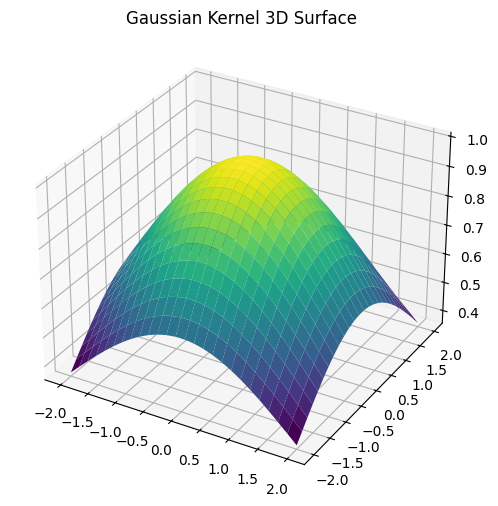

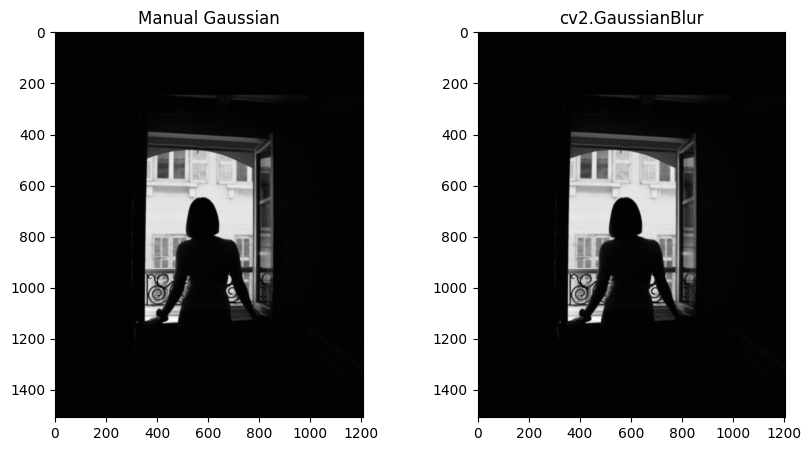

Max difference between manual and opencv: 1.0


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- 5(a) Compute Normalized 5x5 Gaussian Kernel (Sigma=2) ---
sigma = 2
kernel_size = 5
offset = kernel_size // 2  # This is 2. Range will be -2 to 2.

# Create a grid of (x, y) coordinates from -2 to 2
x, y = np.meshgrid(np.arange(-offset, offset + 1), np.arange(-offset, offset + 1))

# Gaussian Formula: (1 / (2*pi*sigma^2)) * exp(-(x^2 + y^2) / (2*sigma^2))
constant = 1 / (2 * np.pi * sigma**2)
exponent = -(x**2 + y**2) / (2 * sigma**2)
kernel = constant * np.exp(exponent)

# Normalize so the sum is 1 (preserves image brightness)
kernel_normalized = kernel / kernel.sum()

print("Manual Kernel Sum:", kernel_normalized.sum())  # Should be 1.0

# --- 5(b) Visualize as 3D Surface Plot ---
# Assignment asks for 51x51 for better visualization, so let's generate a larger one for the plot
x_plot, y_plot = np.meshgrid(np.linspace(-offset, offset, 51), np.linspace(-offset, offset, 51))
kernel_plot = np.exp(-(x_plot**2 + y_plot**2) / (2 * sigma**2)) # Simplified for shape visualization

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x_plot, y_plot, kernel_plot, cmap='viridis')
ax.set_title('Gaussian Kernel 3D Surface')
plt.show()

# --- 5(c) & 5(d) Apply Filtering ---
img = cv2.imread('/content/drive/MyDrive/Assignment1/looking_out.jpg', 0) # Use the woman/window image or any grayscale image

# Apply Manual Kernel using filter2D
manual_blur = cv2.filter2D(img, -1, kernel_normalized)

# Apply OpenCV Built-in Gaussian Blur
opencv_blur = cv2.GaussianBlur(img, (5, 5), sigma)

# Show Comparison
plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(manual_blur, cmap='gray'), plt.title('Manual Gaussian')
plt.subplot(122), plt.imshow(opencv_blur, cmap='gray'), plt.title('cv2.GaussianBlur')
plt.show()

# Calculate difference (should be very close to 0)
diff = np.abs(manual_blur.astype(float) - opencv_blur.astype(float))
print("Max difference between manual and opencv:", diff.max())